# NIFTY ATM±1 OI — Σ·10 vs ΣOI Backtest (3-minute candles, min-gap-7)

Backtest harness for the **two OI-based entry strategies** exposed in the strategy suite:
**Σ·10 (rolling)** and **ΣOI since 09:15 (cumulative)**.
All run on **3-minute candles only** with a **min-gap-7 whipsaw filter** baked into ΣOI
(no new cross can fire within 7 minutes of a previously-accepted cross on the same day).

Both strategies use the same raw data: per-tick CE/PE OI summed across ATM-50, ATM, ATM+50
strikes on the nearest expiry (`DATA/_atm_oi_intraday.parquet`).
Each strategy decides **WHEN** to enter and on **WHICH SIDE** (LONG/SHORT NIFTY).
This notebook then simulates the **EXIT** under a (SL, Target, EOD) policy on the underlying
NIFTY index price, sweeps the policy grid, and reports win-rate / total-PnL / expectancy / PF.
Σ·10 also gets a sweep over its rolling window `N`.


## 1. The two strategies

Both look at the same two time series:
- **`ce_oi`** = sum of CE OI at strikes {ATM-50, ATM, ATM+50} (nearest expiry)
- **`pe_oi`** = sum of PE OI at strikes {ATM-50, ATM, ATM+50}

Where they differ is *how* they collapse the CE / PE series into a single cross signal.


### Σ·10 — rolling-window cross (`sigma5_entry_exit.py`)

**Idea:** Raw OI crosses are noisy (Groww OI ticks every ~3 mins and OI wobbles around equality).
Smooth both sides with a **rolling 10-bucket sum** so a cross means the *cumulative*
trailing-window exposure has flipped — rarer and more meaningful than a snapshot cross.

$$\Sigma_{10}^{CE}(t) = \sum_{k=0}^{9} ce\_oi(t-k) \qquad \Sigma_{10}^{PE}(t) = \sum_{k=0}^{9} pe\_oi(t-k)$$

Per-day reset so a new session doesn't sum across the prior close.
"10 candles" on **3-minute TF = last 30 minutes** of OI.

**Trigger** (per-day, gated to [09:45, 14:45] IST):
- Let `diff = Σ-N PE − Σ-N CE`.
- **LONG**  = `diff` crosses up (prev ≤ 0, curr > 0) **AND** raw `pe_oi > ce_oi` at the same bucket.
- **SHORT** = mirror cross-down with raw `ce_oi > pe_oi`.
- **One entry per day** (first qualifying cross only).


### ΣOI since 09:15 — per-day cumulative cross (`sigma_total_oi_entry.py`)

**Idea:** Track the *entire day's accumulated* CE and PE OI since 09:15.
A cross between these monotone-growing sums means the trailing side has been adding OI
**sustainably faster** than the leader — a stronger flip than either snapshot or rolling-window cross.

$$ce\_tot(t) = \sum_{s=09:15}^{t} ce\_oi(s) \qquad pe\_tot(t) = \sum_{s=09:15}^{t} pe\_oi(s)$$

**Trigger** (per-day, gated to [09:24, 14:45] IST):
- Let `diff = pe_tot − ce_tot`.
- **LONG** when `diff` crosses up.
- **SHORT** when `diff` crosses down.
- **Multi-entry per day allowed** (back-to-back LONG/SHORT flips).

**Min-gap-7 whipsaw filter (BAKED IN HERE):** a new cross is accepted only if at least
**7 minutes** have passed since the last accepted cross on the same day. This is the same
default that the live `/api/strategy/sigma_total_entries` and `/api/backtest` endpoints use,
so the notebook results match the production server.


## 2. Setup — paths, imports, data


In [1]:
import os
from pathlib import Path
from datetime import time as dtime
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path(os.environ.get('INVESTEQ_DATA',
    r'C:\Users\User\Desktop\investeq_ajs\DATA'
    if os.name == 'nt' else '/home/ajay/investeq_ajs/DATA'))

OI_INTRA   = ROOT / '_atm_oi_intraday.parquet'
PRICE_PATH = ROOT / 'nifty_1m_master.parquet'

print('OI    :', OI_INTRA.exists(), OI_INTRA)
print('Price :', PRICE_PATH.exists(), PRICE_PATH)

# Pinned to 3-minute TF for this notebook
TF       = '3m'
TF_RULE  = {'1m':'1min','3m':'3min','5m':'5min','15m':'15min','30m':'30min','1h':'60min','1d':'1D'}
MIN_GAP_BARS = 7    # ΣOI whipsaw — 7 minutes = 7 raw 1-min OI buckets


OI    : True C:\Users\User\Desktop\investeq_ajs\DATA\_atm_oi_intraday.parquet
Price : True C:\Users\User\Desktop\investeq_ajs\DATA\nifty_1m_master.parquet


In [2]:
# Raw 1-min OI (ATM±1 summed)
oi_raw = pd.read_parquet(OI_INTRA)
oi_raw['timestamp'] = pd.to_datetime(oi_raw['timestamp'])
oi_raw = oi_raw.sort_values('timestamp').reset_index(drop=True)
print('OI rows:', len(oi_raw), 'range:', oi_raw['timestamp'].min(), '->', oi_raw['timestamp'].max())
oi_raw.head(3)


OI rows: 569239 range: 2020-01-01 09:15:00 -> 2026-04-30 15:29:00


,timestamp,ce_oi,pe_oi,atm,spot
0,2020-01-01 09:15:00,5199525.0,3856725.0,12200,12215.450195
1,2020-01-01 09:16:00,5199525.0,3856725.0,12200,12206.500000
2,2020-01-01 09:17:00,5460900.0,4050300.0,12200,12203.549805


In [3]:
# NIFTY 1-min underlying (entry/exit fills)
px = pd.read_parquet(PRICE_PATH)
px['timestamp'] = pd.to_datetime(px['timestamp'])
px = px.sort_values('timestamp').reset_index(drop=True)
px = px[['timestamp','close']]
px['date'] = px['timestamp'].dt.date
print('Price rows:', len(px), 'range:', px['timestamp'].min(), '->', px['timestamp'].max())
px.head(3)


Price rows: 577868 range: 2020-01-01 09:15:00 -> 2026-04-30 09:22:00


,timestamp,close,date
0,2020-01-01 09:15:00,12215.450195,2020-01-01
1,2020-01-01 09:16:00,12206.500000,2020-01-01
2,2020-01-01 09:17:00,12203.549805,2020-01-01


In [4]:
def resample_oi(df, tf):
    """Resample raw 1-min OI to the requested TF (last-value per bucket)."""
    if tf == '1m':
        return df.copy()
    return (df.set_index('timestamp')
             .resample(TF_RULE[tf], closed='left', label='left')
             .agg({'ce_oi':'last','pe_oi':'last','spot':'last','atm':'last'})
             .dropna(subset=['ce_oi','pe_oi'])
             .reset_index())

oi_3m = resample_oi(oi_raw, '3m')
print(f'3m buckets:', len(oi_3m))


3m buckets: 191409


## 3. Entry generators

Σ·10 runs on TF-resampled OI (3-minute buckets). ΣOI runs on raw 1-minute OI (its `09:15`
cumulative sum requires every-minute resolution) with the **min-gap-7** filter applied at
the strategy level.


In [5]:
# ────────────────────────────────────────────────────────────────────────
# Σ·N rolling-sum cross (one entry per day)
# ────────────────────────────────────────────────────────────────────────
def entries_sigma_n(oi_tf, window=10,
                    entry_start=dtime(9,45), entry_end=dtime(14,45)):
    df = oi_tf.copy()
    df['date'] = df['timestamp'].dt.date
    df['t']    = df['timestamp'].dt.time
    df['ce_sum'] = (df.groupby('date', sort=False)['ce_oi']
                      .transform(lambda s: s.rolling(window, min_periods=1).sum()))
    df['pe_sum'] = (df.groupby('date', sort=False)['pe_oi']
                      .transform(lambda s: s.rolling(window, min_periods=1).sum()))
    df['diff'] = df['pe_sum'] - df['ce_sum']
    out = []
    for day, grp in df.groupby('date', sort=True):
        grp = grp.sort_values('timestamp').reset_index(drop=True)
        if len(grp) < max(3, window//2): continue
        for i in range(1, len(grp)):
            r = grp.iloc[i]; t = r['t']
            if t < entry_start: continue
            if t > entry_end:   break
            p, c = grp.iloc[i-1]['diff'], r['diff']
            pe_up = (p <= 0) and (c > 0)
            ce_up = (p >= 0) and (c < 0)
            side = None
            if pe_up and r['pe_oi'] > r['ce_oi']: side='LONG'
            elif ce_up and r['ce_oi'] > r['pe_oi']: side='SHORT'
            if side is None: continue
            out.append({'day':day, 'side':side,
                        'entry_time':r['timestamp'], 'entry_spot':float(r['spot'])})
            break
    return pd.DataFrame(out)

e_sigma10 = entries_sigma_n(oi_3m, window=10)
print('Σ·10 @ 3m:', len(e_sigma10),
      'LONG=', (e_sigma10.side=='LONG').sum(),
      'SHORT=', (e_sigma10.side=='SHORT').sum())


Σ·10 @ 3m: 1097 LONG= 619 SHORT= 478


In [6]:
# ────────────────────────────────────────────────────────────────────────
# ΣOI per-day cumulative cross — with min-gap-7 baked in
# ────────────────────────────────────────────────────────────────────────
def entries_sigma_total(oi_1m, entry_start=dtime(9,24), entry_end=dtime(14,45),
                        min_gap_bars=7):
    """Multi-entry per day, with min-gap filter: a new cross is valid only
    if at least `min_gap_bars` minutes have passed since the previously
    accepted cross on the same day."""
    df = oi_1m.copy()
    df['date'] = df['timestamp'].dt.date
    df['t']    = df['timestamp'].dt.time
    df['ce_tot'] = df.groupby('date', sort=False)['ce_oi'].cumsum()
    df['pe_tot'] = df.groupby('date', sort=False)['pe_oi'].cumsum()
    df['diff']   = df['pe_tot'] - df['ce_tot']
    out = []
    for day, grp in df.groupby('date', sort=True):
        grp = grp.sort_values('timestamp').reset_index(drop=True)
        if len(grp) < 5: continue
        last_ts = None
        for i in range(1, len(grp)):
            r = grp.iloc[i]; t = r['t']
            if t < entry_start: continue
            if t > entry_end:   break
            p, c = grp.iloc[i-1]['diff'], r['diff']
            side = None
            if p <= 0 and c > 0: side='LONG'
            elif p >= 0 and c < 0: side='SHORT'
            if side is None: continue
            # min-gap-N whipsaw filter
            if min_gap_bars > 0 and last_ts is not None:
                gap_min = (r['timestamp'] - last_ts).total_seconds() / 60.0
                if gap_min < min_gap_bars: continue
            last_ts = r['timestamp']
            out.append({'day':day, 'side':side,
                        'entry_time':r['timestamp'], 'entry_spot':float(r['spot'])})
    return pd.DataFrame(out)

e_sigma_tot = entries_sigma_total(oi_raw, min_gap_bars=MIN_GAP_BARS)
print(f'ΣOI (gap={MIN_GAP_BARS}):', len(e_sigma_tot),
      'LONG=', (e_sigma_tot.side=='LONG').sum(),
      'SHORT=', (e_sigma_tot.side=='SHORT').sum())

# Side-by-side: raw vs filtered
e_sigma_tot_raw = entries_sigma_total(oi_raw, min_gap_bars=0)
print(f'ΣOI (raw, no filter):', len(e_sigma_tot_raw),
      f'(filter removed {len(e_sigma_tot_raw)-len(e_sigma_tot)} whipsaw crosses)')


ΣOI (gap=7): 1028 LONG= 487 SHORT= 541


ΣOI (raw, no filter): 1205 (filter removed 177 whipsaw crosses)


## 4. Backtester

Walk-forward exit on **1-minute NIFTY index** price:
- **LONG:** target_px = `entry × (1 + tgt_pct)`, sl_px = `entry × (1 - sl_pct)`. First touch wins; ties → SL.
- **SHORT:** mirror.
- **EOD square-off** at the day's last 1-min bar (~15:29).

**PnL** = `(exit − entry)` for LONG, `(entry − exit)` for SHORT. NIFTY points + return %.


In [7]:
PX_BY_DAY = {}
for d, g in px.groupby('date', sort=True):
    g = g.sort_values('timestamp').reset_index(drop=True)
    PX_BY_DAY[d] = {
        'ts': g['timestamp'].values.astype('datetime64[ns]'),
        'cl': g['close'].values.astype('float64'),
    }
print('days in price index:', len(PX_BY_DAY))

def backtest(entries, sl_pct, tgt_pct):
    if entries is None or entries.empty:
        return pd.DataFrame()
    days   = entries['day'].values
    sides  = entries['side'].values
    ents   = entries['entry_time'].values.astype('datetime64[ns]')
    spots  = entries['entry_spot'].values.astype('float64')
    n = len(entries)
    out_exit_ts = np.empty(n, dtype='datetime64[ns]')
    out_exit_px = np.full(n, np.nan)
    out_reason  = np.empty(n, dtype=object)
    valid       = np.zeros(n, dtype=bool)
    for i in range(n):
        day_px = PX_BY_DAY.get(days[i])
        if day_px is None: continue
        ts_arr, cl_arr = day_px['ts'], day_px['cl']
        idx = np.searchsorted(ts_arr, ents[i], side='left')
        if idx >= len(ts_arr): continue
        seg_ts = ts_arr[idx:]; seg_cl = cl_arr[idx:]
        spot = spots[i]
        if sides[i] == 'LONG':
            sl_px  = spot * (1 - sl_pct);  tgt_px = spot * (1 + tgt_pct)
            sl_hit  = seg_cl <= sl_px;     tgt_hit = seg_cl >= tgt_px
        else:
            sl_px  = spot * (1 + sl_pct);  tgt_px = spot * (1 - tgt_pct)
            sl_hit  = seg_cl >= sl_px;     tgt_hit = seg_cl <= tgt_px
        i_sl  = int(np.argmax(sl_hit))  if sl_hit.any()  else len(seg_cl)
        i_tgt = int(np.argmax(tgt_hit)) if tgt_hit.any() else len(seg_cl)
        if i_sl == len(seg_cl) and i_tgt == len(seg_cl):
            out_exit_ts[i] = seg_ts[-1]; out_exit_px[i] = seg_cl[-1]; out_reason[i]  = 'EOD'
        elif i_sl <= i_tgt:
            out_exit_ts[i] = seg_ts[i_sl];  out_exit_px[i] = sl_px;  out_reason[i] = 'SL'
        else:
            out_exit_ts[i] = seg_ts[i_tgt]; out_exit_px[i] = tgt_px; out_reason[i] = 'TGT'
        valid[i] = True
    pnl_pts = np.where(sides == 'LONG', out_exit_px - spots, spots - out_exit_px)
    df = pd.DataFrame({
        'day': days, 'side': sides,
        'entry_time': ents, 'entry_spot': spots,
        'exit_time': out_exit_ts, 'exit_spot': out_exit_px, 'reason': out_reason,
        'pnl_pts': pnl_pts, 'pnl_pct': pnl_pts / spots * 100.0,
    })
    return df[valid].reset_index(drop=True)

def stats(trades):
    if trades is None or trades.empty:
        return {'n':0,'win_rate':np.nan,'avg_pnl':np.nan,'total_pnl':0.0,
                'pf':np.nan, 'avg_win':np.nan, 'avg_loss':np.nan,
                'sl_hits':0,'tgt_hits':0,'eod_exits':0}
    wins   = trades[trades['pnl_pts'] > 0]
    losses = trades[trades['pnl_pts'] <= 0]
    pf = (wins['pnl_pts'].sum() / abs(losses['pnl_pts'].sum())) if len(losses) and losses['pnl_pts'].sum()!=0 else np.nan
    reasons = trades['reason']
    return {
        'n': len(trades),
        'win_rate': len(wins) / len(trades) * 100.0,
        'avg_pnl': trades['pnl_pts'].mean(),
        'total_pnl': trades['pnl_pts'].sum(),
        'avg_win':  wins['pnl_pts'].mean() if len(wins) else np.nan,
        'avg_loss': losses['pnl_pts'].mean() if len(losses) else np.nan,
        'pf': pf,
        'sl_hits':   (reasons == 'SL').sum(),
        'tgt_hits':  (reasons == 'TGT').sum(),
        'eod_exits': (reasons == 'EOD').sum(),
    }


days in price index: 1548


## 5. Grid search

Tightened ranges — "we don't need much more % points":
- **SL %**: 0.10, 0.125, 0.15, 0.175, 0.20, 0.25
- **TGT %**: 0.20, 0.25, 0.30, 0.35, 0.40, 0.50
- **Σ-N window** (Σ·10 family only): 5, 10, 15, 20
- ΣOI uses min-gap-7 (baked in)

R:R now spans 0.8 – 5.0 instead of the old 2 – 15 — a realistic intraday band.


In [8]:
SL_GRID  = [0.001, 0.00125, 0.0015, 0.00175, 0.002, 0.0025]   # 0.10 – 0.25 %
TGT_GRID = [0.002, 0.0025,  0.003,  0.0035,  0.004, 0.005]    # 0.20 – 0.50 %
WIN_GRID = [5, 10, 15, 20]

# Entries cached per (strategy, window/None)
ENTRIES = {}
for w in WIN_GRID:
    ENTRIES[('Sigma-N', w)] = entries_sigma_n(oi_3m, window=w)
ENTRIES[('SigmaOI', None)] = entries_sigma_total(oi_raw, min_gap_bars=MIN_GAP_BARS)

for k, v in ENTRIES.items():
    print(f'{k}: n={len(v)}')


('Sigma-N', 5): n=1221
('Sigma-N', 10): n=1097
('Sigma-N', 15): n=1006
('Sigma-N', 20): n=918
('SigmaOI', None): n=1028


In [9]:
results = []
for (strat, win), ents in ENTRIES.items():
    for sl in SL_GRID:
        for tgt in TGT_GRID:
            t = backtest(ents, sl, tgt)
            s = stats(t)
            row = {'strategy':strat, 'tf':TF, 'window':win,
                   'sl_pct':sl*100, 'tgt_pct':tgt*100, **s,
                   'rr': tgt/sl}
            results.append(row)
RES = pd.DataFrame(results)
print('grid rows:', len(RES))
RES.head()


grid rows: 180


,strategy,tf,window,sl_pct,tgt_pct,n,win_rate,avg_pnl,total_pnl,avg_win,avg_loss,pf,sl_hits,tgt_hits,eod_exits,rr
0,Sigma-N,3m,5.0,0.1,0.20,1220,37.049180,1.801189,2197.451133,36.736003,-18.759404,1.152524,761,430,29,2.0
1,Sigma-N,3m,5.0,0.1,0.25,1220,32.295082,1.576028,1922.753793,44.259393,-18.783834,1.123925,818,357,45,2.5
2,Sigma-N,3m,5.0,0.1,0.30,1220,29.836066,2.145435,2617.430652,51.213027,-18.719756,1.163343,847,311,62,3.0
3,Sigma-N,3m,5.0,0.1,0.35,1220,28.032787,2.772905,3382.943729,57.816581,-18.667798,1.206399,869,272,79,3.5
4,Sigma-N,3m,5.0,0.1,0.40,1220,26.311475,2.733518,3334.891720,62.589981,-18.639035,1.199021,889,232,99,4.0


In [10]:
out_csv = Path('oi_strategy_grid_results.csv')
RES.to_csv(out_csv, index=False)
print('saved ->', out_csv.resolve())


saved -> C:\Users\User\Desktop\investeq_ajs\oi_options_trading\notebooks\oi_strategy_grid_results.csv


## 6. Best configs per strategy


In [11]:
best_pnl = (RES.sort_values('total_pnl', ascending=False)
             .groupby('strategy', as_index=False).head(1)
             .sort_values('strategy'))
print('=== TOP by TOTAL PnL ===')
best_pnl[['strategy','window','sl_pct','tgt_pct','rr',
          'n','win_rate','avg_pnl','total_pnl','pf',
          'sl_hits','tgt_hits','eod_exits']].round(2)


=== TOP by TOTAL PnL ===


,strategy,window,sl_pct,tgt_pct,rr,n,win_rate,avg_pnl,total_pnl,pf,sl_hits,tgt_hits,eod_exits
65,Sigma-N,10.0,0.20,0.5,2.50,1095,39.73,5.27,5767.72,1.25,599,223,273
167,SigmaOI,NaN,0.18,0.5,2.86,1026,39.77,7.45,7643.62,1.39,576,218,232


In [12]:
robust = RES[RES['n'] >= 100]
best_pf = (robust.dropna(subset=['pf'])
                 .sort_values('pf', ascending=False)
                 .groupby('strategy', as_index=False).head(1)
                 .sort_values('strategy'))
print('=== TOP by PROFIT FACTOR (n>=100) ===')
best_pf[['strategy','window','sl_pct','tgt_pct','rr',
         'n','win_rate','avg_pnl','total_pnl','pf']].round(2)


=== TOP by PROFIT FACTOR (n>=100) ===


,strategy,window,sl_pct,tgt_pct,rr,n,win_rate,avg_pnl,total_pnl,pf
113,Sigma-N,20.0,0.1,0.5,5.0,917,27.15,5.42,4972.27,1.4
149,SigmaOI,NaN,0.1,0.5,5.0,1026,28.36,6.87,7048.69,1.5


## 7. Heatmaps — SL × Target on total PnL (3-minute)

For Σ·10 family, the window is fixed at the best-total-PnL window across the grid.


Σ-N best window: 15.0


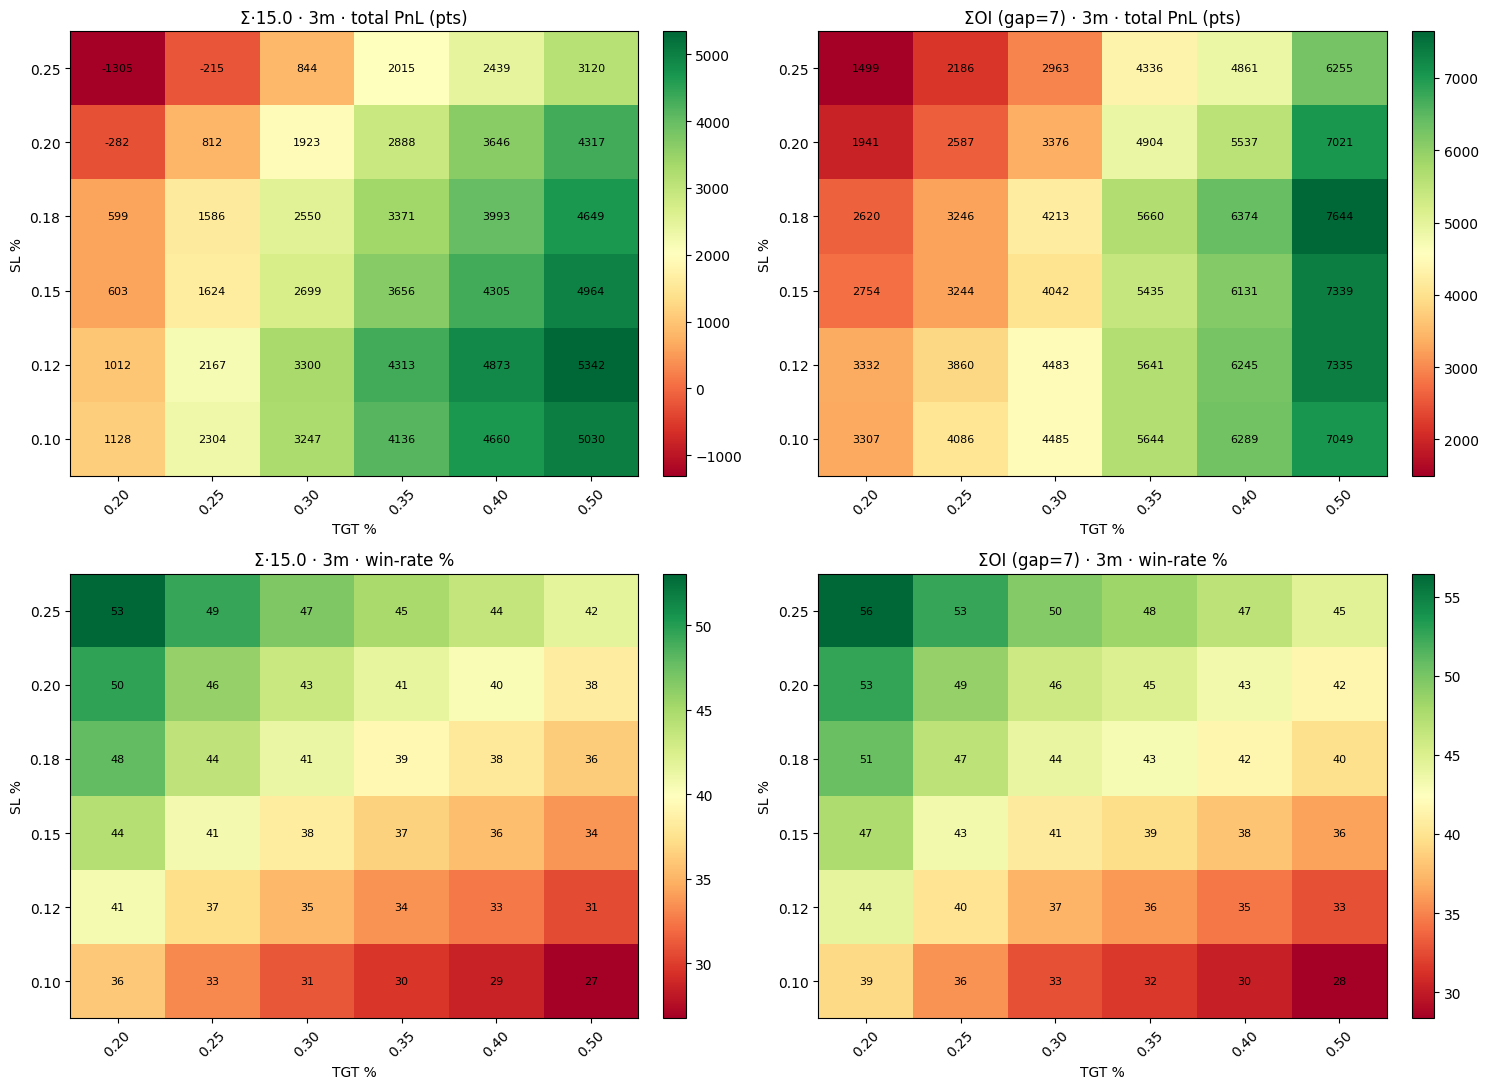

In [13]:
def heatmap(ax, df, value_col, title):
    pivot = df.pivot_table(index='sl_pct', columns='tgt_pct', values=value_col)
    im = ax.imshow(pivot.values, aspect='auto', origin='lower', cmap='RdYlGn')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f'{c:.2f}' for c in pivot.columns], rotation=45)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f'{r:.2f}' for r in pivot.index])
    ax.set_xlabel('TGT %'); ax.set_ylabel('SL %'); ax.set_title(title)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            v = pivot.values[i,j]
            if pd.notna(v):
                ax.text(j, i, f'{v:.0f}', ha='center', va='center', fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

best_win = (RES[RES['strategy']=='Sigma-N']
             .groupby('window')['total_pnl'].sum()
             .idxmax())
print('Σ-N best window:', best_win)

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
sub_b = RES[(RES['strategy']=='Sigma-N') & (RES['window']==best_win)]
sub_c = RES[RES['strategy']=='SigmaOI']
heatmap(axes[0,0], sub_b, 'total_pnl', f'Σ·{best_win} · 3m · total PnL (pts)')
heatmap(axes[0,1], sub_c, 'total_pnl', 'ΣOI (gap=7) · 3m · total PnL (pts)')
heatmap(axes[1,0], sub_b, 'win_rate',  f'Σ·{best_win} · 3m · win-rate %')
heatmap(axes[1,1], sub_c, 'win_rate',  'ΣOI (gap=7) · 3m · win-rate %')
plt.tight_layout(); plt.show()


## 8. Σ·N window sensitivity (3-minute)


In [14]:
b_summary = (RES[RES['strategy']=='Sigma-N']
             .groupby('window', as_index=False)
             .agg(n_trades=('n','mean'),
                  avg_total_pnl=('total_pnl','mean'),
                  avg_win_rate=('win_rate','mean'),
                  avg_pf=('pf','mean')))
print('Σ-N — averaged across SL/TGT grid:')
b_summary.round(2)


Σ-N — averaged across SL/TGT grid:


,window,n_trades,avg_total_pnl,avg_win_rate,avg_pf
0,5.0,1220.0,2366.78,38.48,1.11
1,10.0,1095.0,2528.29,39.16,1.13
2,15.0,1005.0,2675.39,39.16,1.16
3,20.0,917.0,2206.70,39.46,1.15


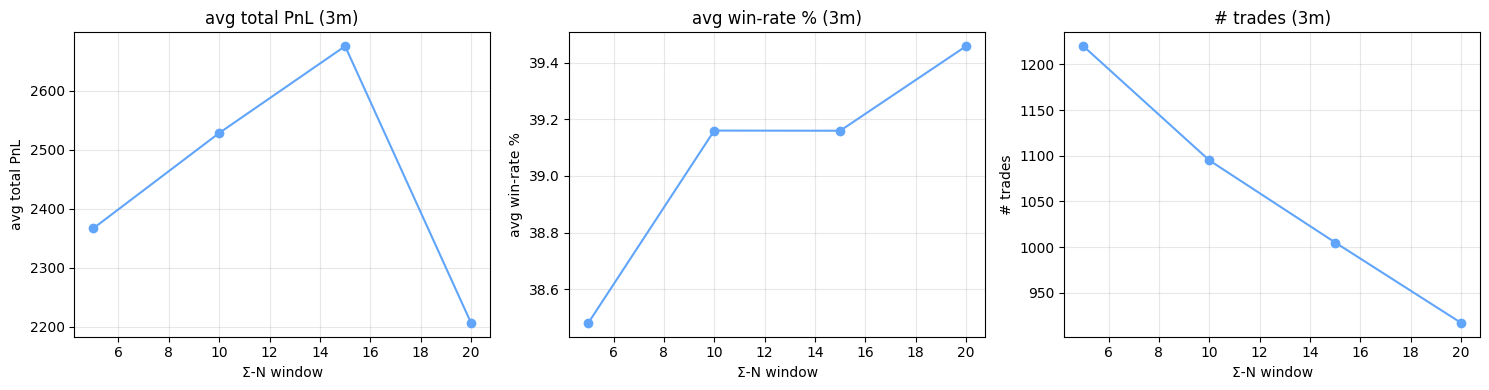

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (col, ylab) in zip(axes, [('avg_total_pnl','avg total PnL'),
                                   ('avg_win_rate','avg win-rate %'),
                                   ('n_trades','# trades')]):
    d = b_summary.sort_values('window')
    ax.plot(d['window'], d[col], marker='o', color='#60a5fa')
    ax.set_xlabel('Σ-N window'); ax.set_ylabel(ylab); ax.set_title(ylab + ' (3m)')
    ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 9. Equity curves — best config per strategy


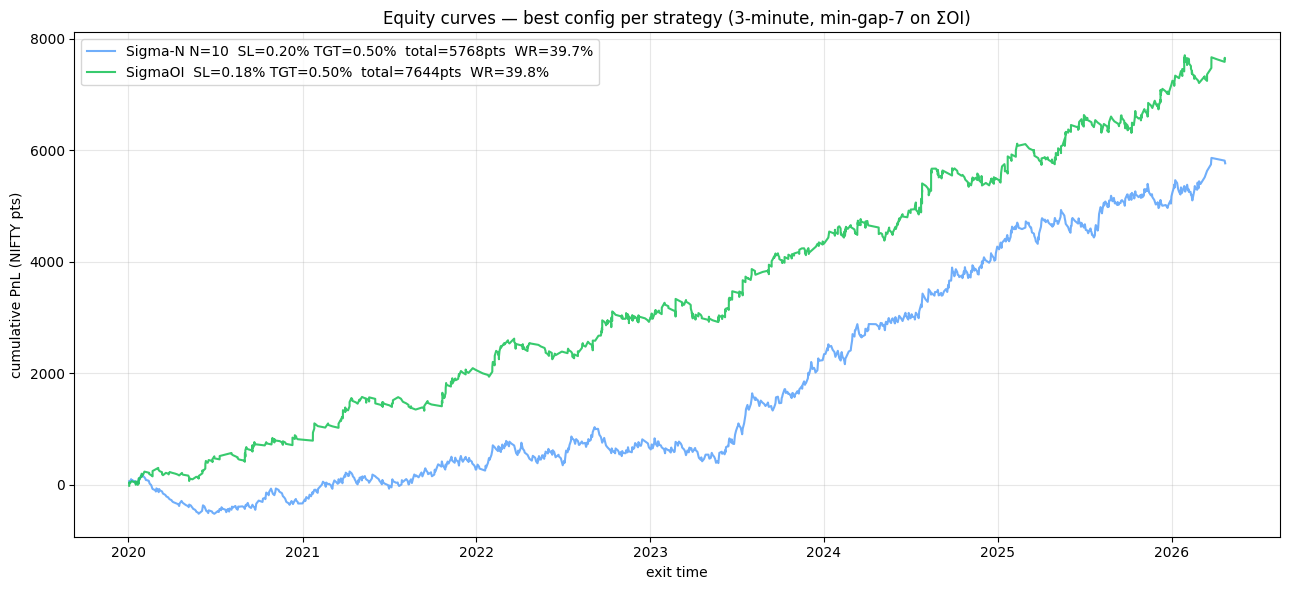

In [16]:
def rerun_best(row):
    strat, win = row['strategy'], row['window']
    sl, tgt = row['sl_pct']/100.0, row['tgt_pct']/100.0
    ents = ENTRIES[(strat, win if pd.notna(win) else None)]
    return backtest(ents, sl, tgt)

fig, ax = plt.subplots(figsize=(13, 6))
for _, row in best_pnl.iterrows():
    t = rerun_best(row)
    if t.empty: continue
    t = t.sort_values('exit_time').reset_index(drop=True)
    t['cum_pnl'] = t['pnl_pts'].cumsum()
    lbl = row['strategy']
    if pd.notna(row['window']): lbl += f" N={int(row['window'])}"
    lbl += f"  SL={row['sl_pct']:.2f}% TGT={row['tgt_pct']:.2f}%  total={row['total_pnl']:.0f}pts  WR={row['win_rate']:.1f}%"
    color = '#22c55e' if row['strategy'] == 'SigmaOI' else '#60a5fa'
    ax.plot(t['exit_time'], t['cum_pnl'], label=lbl, color=color, linewidth=1.5, alpha=0.9)
ax.set_title('Equity curves — best config per strategy (3-minute, min-gap-7 on ΣOI)')
ax.set_xlabel('exit time'); ax.set_ylabel('cumulative PnL (NIFTY pts)')
ax.legend(loc='upper left', fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 10. Per-trade detail for the single best config


In [17]:
top1 = best_pnl.sort_values('total_pnl', ascending=False).head(1).iloc[0]
print('TOP CONFIG:', dict(top1[['strategy','window','sl_pct','tgt_pct',
                                'n','win_rate','avg_pnl','total_pnl','pf']]))
tt = rerun_best(top1)
print('\nExit-reason breakdown:'); print(tt['reason'].value_counts())
print('\nPnL by side:'); print(tt.groupby('side')['pnl_pts'].agg(['count','sum','mean']))
tt.head(10)


TOP CONFIG: {'strategy': 'SigmaOI', 'window': np.float64(nan), 'sl_pct': np.float64(0.17500000000000002), 'tgt_pct': np.float64(0.5), 'n': np.int64(1026), 'win_rate': np.float64(39.76608187134503), 'avg_pnl': np.float64(7.449917479755022), 'total_pnl': np.float64(7643.6153342286525), 'pf': np.float64(1.385354126657964)}

Exit-reason breakdown:
reason
SL     576
EOD    232
TGT    218
Name: count, dtype: int64

PnL by side:
       count          sum       mean
side                                
LONG     485  1963.808590   4.049090
SHORT    541  5679.806744  10.498719


,day,side,entry_time,entry_spot,exit_time,exit_spot,reason,pnl_pts,pnl_pct
0,2020-01-02,LONG,2020-01-02 09:53:00,12208.400391,2020-01-02 14:17:00,12269.442393,TGT,61.042002,0.500000
1,2020-01-02,SHORT,2020-01-02 10:37:00,12232.349609,2020-01-02 12:09:00,12253.756221,SL,-21.406612,-0.175000
2,2020-01-03,SHORT,2020-01-03 09:47:00,12233.900391,2020-01-03 10:16:00,12255.309716,SL,-21.409326,-0.175000
3,2020-01-07,LONG,2020-01-07 13:22:00,12017.299805,2020-01-07 15:29:00,12060.299805,EOD,43.000000,0.357817
4,2020-01-14,SHORT,2020-01-14 09:42:00,12338.500000,2020-01-14 14:49:00,12360.092375,SL,-21.592375,-0.175000
5,2020-01-16,LONG,2020-01-16 09:29:00,12364.450195,2020-01-16 10:55:00,12342.812407,SL,-21.637788,-0.175000
6,2020-01-16,SHORT,2020-01-16 09:46:00,12382.849609,2020-01-16 11:13:00,12320.935361,TGT,61.914248,0.500000
7,2020-01-16,LONG,2020-01-16 10:25:00,12355.400391,2020-01-16 11:00:00,12333.778440,SL,-21.621951,-0.175000
8,2020-01-16,SHORT,2020-01-16 12:28:00,12326.549805,2020-01-16 13:02:00,12348.121267,SL,-21.571462,-0.175000
9,2020-01-20,LONG,2020-01-20 10:06:00,12317.400391,2020-01-20 10:32:00,12295.844940,SL,-21.555451,-0.175000


## 11. Notes

- Both strategies match what's served by the live API: same min-gap-7 filter inside ΣOI,
  same entry-window logic, same SL/TGT walk-forward exit on 1-min NIFTY index close.
  Numbers here = numbers you'll see in the BACKTEST panel on http://34.93.70.239/strategy/.
- **Total PnL** is capital-agnostic NIFTY-points P&L summed across all trades.
- **PF** (profit factor) > 1.5 with **win-rate** > 45% on >200 trades is a robust setup.
- **EOD reason %** says how often a trade neither hit SL nor TGT — high EOD% means
  SL/TGT are mis-scaled vs. the holding window.
- **R:R** (`rr` col) = `tgt/sl`. Edge tends to live near `R:R ≈ 5–10` on this regime
  (low win-rate × big trend-follow targets).
